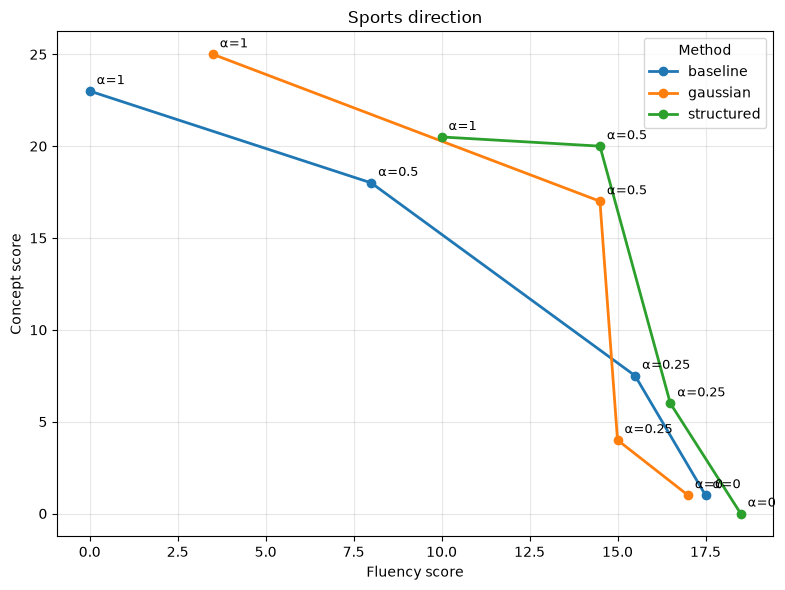

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("results.xlsx", engine="openpyxl")

sports = (
    df[df["direction_id"].str.lower() == "sports"]
    .sort_values(["method", "alpha"])
)

fig, ax = plt.subplots(figsize=(8, 6))

for method, group in sports.groupby("method", sort=False):
    ax.plot(
        group["fluency_sum"],
        group["concept_sum"],
        marker="o",
        linewidth=2,
        label=method,
    )

    for _, row in group.iterrows():
        ax.annotate(
            f"α={row['alpha']:g}",
            (row["fluency_sum"], row["concept_sum"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9,
        )

ax.set_xlabel("Fluency score")
ax.set_ylabel("Concept score")
ax.set_title("Sports direction")
ax.grid(alpha=0.3)
ax.legend(title="Method")
plt.tight_layout()
plt.show()